# House Price Prediction Using Machine Learning

Name: Pinaki Priya

Objective:
To predict house prices using property features and compare the performance of Linear Regression and Random Forest Regression models.

In [1]:
# Importing the libraries needed for this project

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import zipfile
import os

In [3]:
# Extracting the uploaded zip file

zip_path = "/archive (9).zip"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall("housing_dataset")

print("Dataset extracted successfully.")

Dataset extracted successfully.


In [4]:
# Checking what files were extracted

os.listdir("housing_dataset")

['Housing.csv']

In [5]:
for file in os.listdir("housing_dataset"):
    print(file)

Housing.csv


In [6]:
# Loading the housing dataset

df = pd.read_csv("housing_dataset/Housing.csv")

print("Dataset loaded successfully.")

Dataset loaded successfully.


In [7]:
# Viewing the first 10 records

df.head(10)

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
5,10850000,7500,3,3,1,yes,no,yes,no,yes,2,yes,semi-furnished
6,10150000,8580,4,3,4,yes,no,no,no,yes,2,yes,semi-furnished
7,10150000,16200,5,3,2,yes,no,no,no,no,0,no,unfurnished
8,9870000,8100,4,1,2,yes,yes,yes,no,yes,2,yes,furnished
9,9800000,5750,3,2,4,yes,yes,no,no,yes,1,yes,unfurnished


In [8]:
# Checking number of rows and columns

print("Number of rows :", df.shape[0])
print("Number of columns :", df.shape[1])

Number of rows : 545
Number of columns : 13


In [9]:
# Listing all column names

print("Columns in the dataset:\n")

for col in df.columns:
    print(col)

Columns in the dataset:

price
area
bedrooms
bathrooms
stories
mainroad
guestroom
basement
hotwaterheating
airconditioning
parking
prefarea
furnishingstatus


In [10]:
# Target variable and feature variables

target_column = "price"

feature_columns = df.columns.drop(target_column)

print("Target Column:")
print(target_column)

print("\nFeature Columns:")
print(list(feature_columns))

Target Column:
price

Feature Columns:
['area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefarea', 'furnishingstatus']


In [11]:
# Checking the datatype of each column

df.dtypes

,0
price,int64
area,int64
bedrooms,int64
bathrooms,int64
stories,int64
mainroad,object
guestroom,object
basement,object
hotwaterheating,object
airconditioning,object


In [12]:
# Checking if any column contains missing values

df.isnull().sum()

,0
price,0
area,0
bedrooms,0
bathrooms,0
stories,0
mainroad,0
guestroom,0
basement,0
hotwaterheating,0
airconditioning,0


In [13]:
# Summary statistics for numerical columns

df.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


In [14]:
# Checking duplicate records

duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 0


Observation:

The dataset contains information related to house characteristics such as area, number of bedrooms, bathrooms, stories, parking facilities, and several yes/no amenities. The target variable is price. Before building a machine learning model, the data needs to be checked for missing values, duplicate records, and categorical variables that must be converted into numerical form.

In [15]:
# Checking missing values in each column

missing_values = df.isnull().sum()

print(missing_values)

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64


In [16]:
# Total missing values in the dataset

print("Total missing values:", missing_values.sum())

Total missing values: 0


In [17]:
# Creating a copy so the original data remains unchanged

housing_df = df.copy()

In [18]:
# Finding categorical columns

categorical_columns = housing_df.select_dtypes(include='object').columns

print("Categorical Columns:")
print(list(categorical_columns))

Categorical Columns:
['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea', 'furnishingstatus']


In [19]:
# Converting categorical columns into numerical form

housing_df = pd.get_dummies(
    housing_df,
    columns=categorical_columns,
    drop_first=True
)

housing_df.head()

,price,area,bedrooms,bathrooms,stories,parking,mainroad_yes,guestroom_yes,basement_yes,hotwaterheating_yes,airconditioning_yes,prefarea_yes,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,2,True,False,False,False,True,True,False,False
1,12250000,8960,4,4,4,3,True,False,False,False,True,False,False,False
2,12250000,9960,3,2,2,2,True,False,True,False,False,True,True,False
3,12215000,7500,4,2,2,3,True,False,True,False,True,True,False,False
4,11410000,7420,4,1,2,2,True,True,True,False,True,False,False,False


In [20]:
# Shape after encoding

print("New dataset shape:", housing_df.shape)

New dataset shape: (545, 14)


In [21]:
# Checking data types after encoding

housing_df.dtypes

,0
price,int64
area,int64
bedrooms,int64
bathrooms,int64
stories,int64
parking,int64
mainroad_yes,bool
guestroom_yes,bool
basement_yes,bool
hotwaterheating_yes,bool


Data Cleaning Summary

The dataset was checked for missing values and duplicate records. No duplicate rows were found. Categorical variables such as mainroad, guestroom, basement, airconditioning, and furnishingstatus were converted into numerical format using one-hot encoding so that they could be used by machine learning algorithms.

In [22]:
# Separating input features and target variable

X = housing_df.drop("price", axis=1)

y = housing_df["price"]

print("Feature matrix shape:", X.shape)
print("Target variable shape:", y.shape)

Feature matrix shape: (545, 13)
Target variable shape: (545,)


In [23]:
from sklearn.model_selection import train_test_split

# Splitting data into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)

Training data shape: (436, 13)
Testing data shape: (109, 13)


In [24]:
from sklearn.linear_model import LinearRegression

# Creating and training Linear Regression model

linear_model = LinearRegression()

linear_model.fit(X_train, y_train)

print("Linear Regression model trained successfully.")

Linear Regression model trained successfully.


In [25]:
# Predicting house prices using Linear Regression

lr_predictions = linear_model.predict(X_test)

print("First 5 predictions:\n")

print(lr_predictions[:5])

First 5 predictions:

[5164653.90033968 7224722.29802167 3109863.24240338 4612075.3272256
 3294646.25725955]


In [26]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

# Calculating evaluation metrics

lr_mae = mean_absolute_error(y_test, lr_predictions)

lr_rmse = mean_squared_error(
    y_test,
    lr_predictions
) ** 0.5

lr_r2 = r2_score(
    y_test,
    lr_predictions
)

print("Linear Regression Performance")
print("-" * 35)

print("MAE :", round(lr_mae, 2))
print("RMSE:", round(lr_rmse, 2))
print("R² Score:", round(lr_r2, 4))

Linear Regression Performance
-----------------------------------
MAE : 970043.4
RMSE: 1324506.96
R² Score: 0.6529


Linear Regression was used as the first baseline model for predicting house prices. The model was trained using 80% of the dataset and evaluated on the remaining 20%. The MAE, RMSE, and R² Score were calculated to measure prediction accuracy.

In [27]:
from sklearn.ensemble import RandomForestRegressor

# Training Random Forest model

rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

print("Random Forest model trained successfully.")

Random Forest model trained successfully.


In [28]:
# Predicting house prices using Random Forest

rf_predictions = rf_model.predict(X_test)

print("First 5 predictions:\n")

print(rf_predictions[:5])

First 5 predictions:

[5377680.   7287070.   3747528.75 4502120.   3748885.  ]


In [29]:
# Evaluating Random Forest performance

rf_mae = mean_absolute_error(
    y_test,
    rf_predictions
)

rf_rmse = mean_squared_error(
    y_test,
    rf_predictions
) ** 0.5

rf_r2 = r2_score(
    y_test,
    rf_predictions
)

print("Random Forest Performance")
print("-" * 35)

print("MAE :", round(rf_mae, 2))
print("RMSE:", round(rf_rmse, 2))
print("R² Score:", round(rf_r2, 4))

Random Forest Performance
-----------------------------------
MAE : 1021546.04
RMSE: 1400565.97
R² Score: 0.6119


In [30]:
# Comparing model performances

comparison = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "MAE": [lr_mae, rf_mae],
    "RMSE": [lr_rmse, rf_rmse],
    "R2 Score": [lr_r2, rf_r2]
})

comparison

,Model,MAE,RMSE,R2 Score
0,Linear Regression,9.700434e+05,1.324507e+06,0.652924
1,Random Forest,1.021546e+06,1.400566e+06,0.611919


Model Comparison

Two regression models were trained and evaluated. Linear Regression served as a baseline model, while Random Forest Regressor was used to capture more complex relationships between house features and prices. The model with the lower error values and higher R² Score will be considered the better-performing model.

In [31]:
# Creating folder to save chart images

import os

os.makedirs("charts", exist_ok=True)

print("Charts folder created.")

Charts folder created.


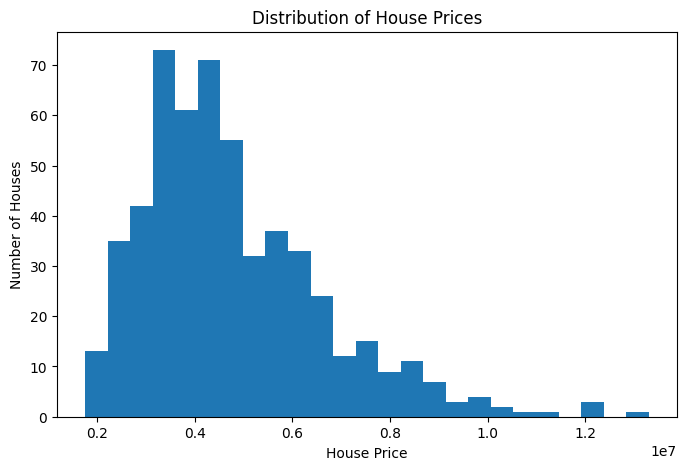

In [32]:
# Distribution of house prices

plt.figure(figsize=(8,5))

plt.hist(df["price"], bins=25)

plt.title("Distribution of House Prices")
plt.xlabel("House Price")
plt.ylabel("Number of Houses")

plt.savefig("charts/price_distribution.png")

plt.show()

Observation:

Most houses are concentrated in the lower and middle price ranges, while only a few houses have very high prices.

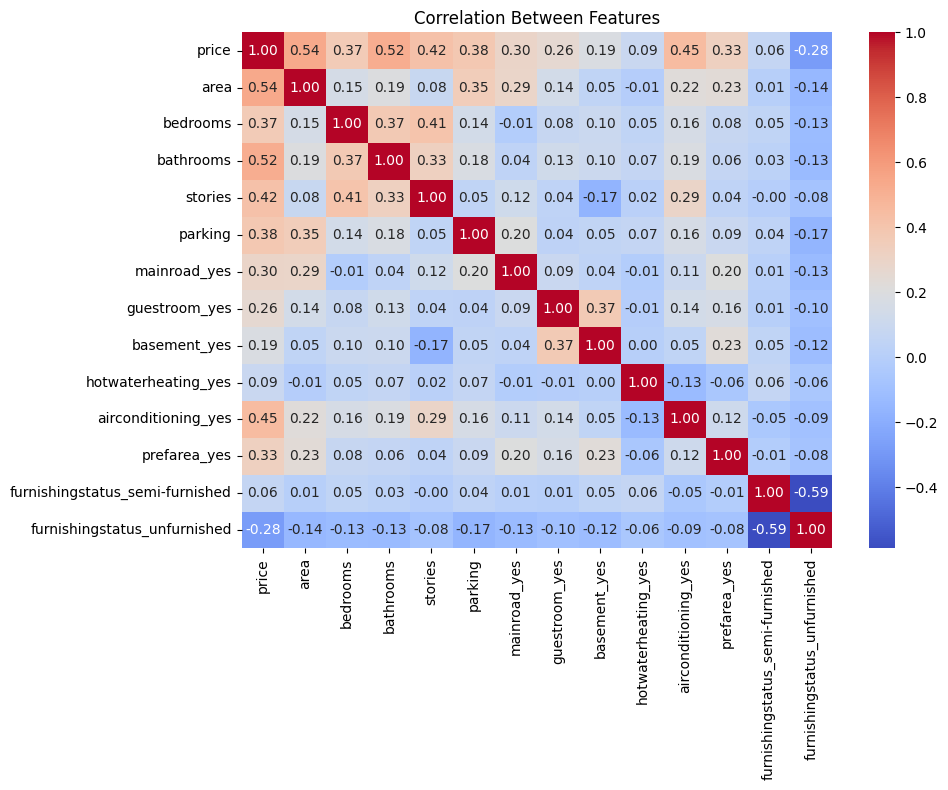

In [33]:
# Correlation heatmap

plt.figure(figsize=(10,8))

sns.heatmap(
    housing_df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Between Features")

plt.tight_layout()

plt.savefig("charts/correlation_heatmap.png")

plt.show()

Observation:

The heatmap helps identify which variables have the strongest positive or negative relationship with house price.

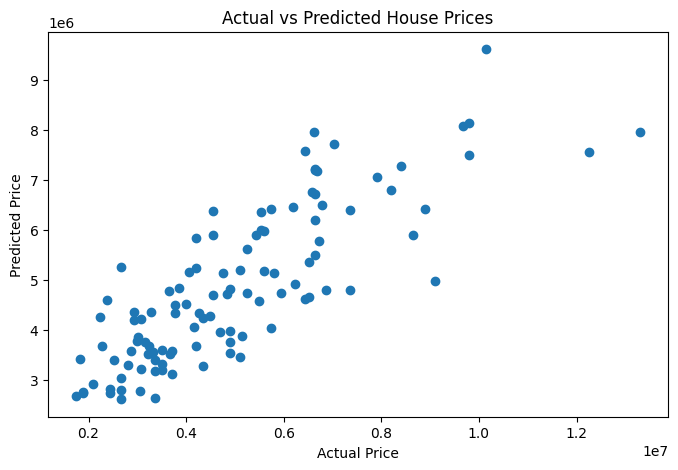

In [34]:
# Actual vs Predicted prices using Linear Regression

plt.figure(figsize=(8,5))

plt.scatter(
    y_test,
    lr_predictions
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")

plt.title("Actual vs Predicted House Prices")

plt.savefig("charts/actual_vs_predicted.png")

plt.show()

Observation:

Most points follow a positive trend, indicating that the model is able to predict house prices reasonably well, although some prediction errors are present.

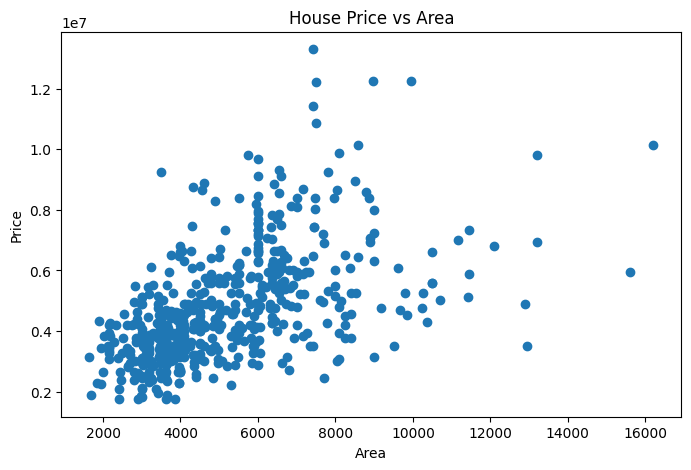

In [35]:
# Relationship between area and house price

plt.figure(figsize=(8,5))

plt.scatter(
    df["area"],
    df["price"]
)

plt.xlabel("Area")
plt.ylabel("Price")

plt.title("House Price vs Area")

plt.savefig("charts/price_vs_area.png")

plt.show()

Insights and Summary

The objective of this project was to predict house prices using machine learning techniques. After exploring and cleaning the dataset, both Linear Regression and Random Forest Regressor models were trained and evaluated.

The correlation analysis showed that area, bathrooms, stories, parking, and air conditioning had a noticeable influence on house prices. Larger houses with more amenities generally tended to have higher prices.

The Linear Regression model achieved an R² score of 0.6529, which means it was able to explain approximately 65% of the variation in house prices. Surprisingly, Linear Regression performed better than Random Forest Regressor on this dataset, indicating that the relationship between the features and house prices is relatively linear.

One interesting observation was that house area appeared to have a strong impact on price compared to several other features.

Based on these findings, a real estate business should focus on highlighting property size and key amenities such as parking, air conditioning, and number of bathrooms when pricing and marketing properties.

In [36]:
# Final comparison of both models

comparison = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "MAE": [round(lr_mae, 2), round(rf_mae, 2)],
    "RMSE": [round(lr_rmse, 2), round(rf_rmse, 2)],
    "R2 Score": [round(lr_r2, 4), round(rf_r2, 4)]
})

comparison

,Model,MAE,RMSE,R2 Score
0,Linear Regression,970043.40,1324506.96,0.6529
1,Random Forest,1021546.04,1400565.97,0.6119
